# Ingeniería de Variables (Feature Engineering): El Problema Espacial

**Objetivo:** La regresión lineal clásica fracasa al interpretar coordenadas geográficas (latitud y longitud) porque asume relaciones monótonas en un plano rígido, ignorando los "epicentros" de riqueza en California (ej. San Francisco, Los Ángeles). 

En este notebook:
1. Engañar a la linealidad mediante **Feature Crosses** (cruces condicionales).
2. Transformar el espacio continuo en zonas discretas mediante **Spatial Binning (K-Means)**.

El resultado final será una matriz de datos enriquecida, lista para ser devorada por el modelo lineal.

### Inicialización y Carga

In [1]:
import pandas as pd
import numpy as np
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import seaborn as sns

#cargar datos limpios del analisis EDA anterior
df = pd.read_csv('../data/processed/housing_clean.csv')
print(f"Base cargada. Dimensiones iniciales: {df.shape}")

Base cargada. Dimensiones iniciales: (19087, 13)


## Interacciones Condicionales (Feature Crosses)
La matriz de Pearson es ciega a los contextos. Una casa antigua pierde valor, *a menos* que esté en un barrio de altos ingresos (casa histórica). Un precio sube por el tamaño, *a menos* que haya demasiadas personas viviendo ahí (hacinamiento). 

Inyectar estas dos nuevas dimensiones matemáticas multiplicando y dividiendo variables existentes para que el modelo lineal asigne pesos a estos contextos específicos.

In [2]:
#interaccion edad-ingreso
df['age_x_income'] = df['housing_median_age'] * df['median_income']

#ratio de hacinamiento
df['population_per_room'] = df['population'] / df['total_rooms']

print("Feature Crosses inyectados en la matriz.")

Feature Crosses inyectados en la matriz.


## Discretización del Espacio (Spatial Binning con K-Means)
La latitud y longitud puras no significan nada para el algoritmo predictivo. Utilizar aprendizaje no supervisado (K-Means Clustering) para leer *únicamente* las coordenadas y agrupar el estado de California en 10 macro-zonas o epicentros. 

Esto transforma un problema de "coordenadas infinitas" en una variable categórica finita que el modelo lineal puede usar como un "escalón" de precio.

In [3]:
#solo 10 epicentros
n_clusters = 10

#extraer coordenadas
coords = df[['latitude', 'longitude']]

#entrenar el agrupador espacial
kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
df['geo_cluster'] = kmeans.fit_predict(coords)

#convertir el cluster en texto para que el modelo no asuma el valor por su clasificacion numerica
df['geo_cluster'] = df['geo_cluster'].astype(str) 

print(f"Mapa dividido en {n_clusters} zonas geográficas discretas.")

Mapa dividido en 10 zonas geográficas discretas.


## Auditoría Visual de la Arquitectura Espacial
Desplegar el mapa de dispersión coloreado por los nuevos "Clusters" para verificar que K-Means haya logrado aislar lógicamente las bahías, el interior y las zonas sur del estado.

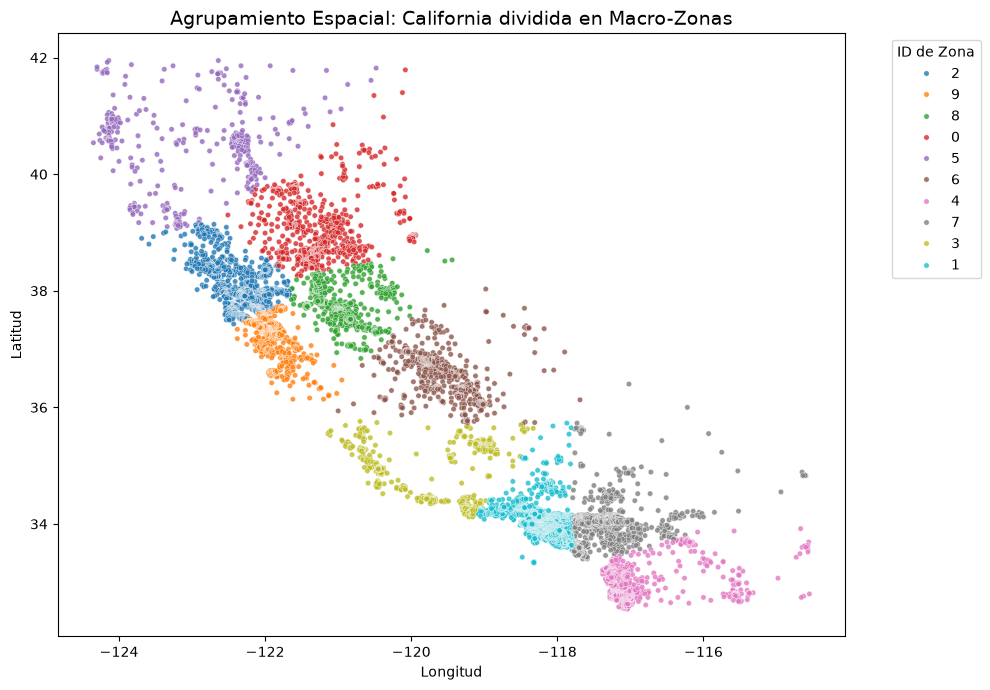

In [4]:
#graficar el mapa de California coloreado por las nuevas zonas
plt.figure(figsize=(10, 7))
sns.scatterplot(
    data=df, 
    x='longitude', 
    y='latitude', 
    hue='geo_cluster', 
    palette='tab10', 
    s=15, 
    alpha=0.8
)
plt.title("Agrupamiento Espacial: California dividida en Macro-Zonas", fontsize=14)
plt.xlabel("Longitud")
plt.ylabel("Latitud")
plt.legend(title='ID de Zona', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

## Traducción Algorítmica y Exportación
El algoritmo espacial hizo su trabajo agrupando las coordenadas. Para inyectar esto en la Regresión Lineal sin provocar **Data Leakage** (Fuga de Datos al calcular medias de precios de forma prematura), transformar las zonas en variables binarias independientes mediante One-Hot Encoding. 

Finalmente, exportar la nueva matriz hiper-enriquecida, lista para ser evaluada.

In [5]:
#convertir los clusters en variables binarias (0 o 1)
df_final = pd.get_dummies(df, columns=['geo_cluster', 'ocean_proximity'], drop_first=True).astype(int)

#eliminar columnas que no van al modelo
columnas_a_eliminar = [
    'total_rooms',              #reemplazada por ratios
    'total_bedrooms',           #reemplazada por ratios
    'population',               #reemplazada por ratios
    'households',               #reemplazada por ratios
    'bedrooms_per_room',        #multicolinealidad -0.83 con rooms_per_household
    'population_per_household', #redundante - derivada de population_per_room
    'latitude',                 #reemplazada por geo_clusters
    'longitude',                #reemplazada por geo_clusters
]

df_final = df_final.drop(columns=columnas_a_eliminar)

#exportar la matriz enriquecida cruda para el modelo
df_final.to_csv('../data/processed/housing_features_engineered.csv', index=False)

print(f"Columnas en la matriz final: {df_final.shape[1]}")
print(df_final.columns.tolist())

Columnas en la matriz final: 19
['housing_median_age', 'median_income', 'median_house_value', 'rooms_per_household', 'age_x_income', 'population_per_room', 'geo_cluster_1', 'geo_cluster_2', 'geo_cluster_3', 'geo_cluster_4', 'geo_cluster_5', 'geo_cluster_6', 'geo_cluster_7', 'geo_cluster_8', 'geo_cluster_9', 'ocean_proximity_INLAND', 'ocean_proximity_ISLAND', 'ocean_proximity_NEAR BAY', 'ocean_proximity_NEAR OCEAN']
